In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Initialization of Neural Network Parameters


When it comes to deep neural nets, you should be careful about how you initialize the weights. Bad initialization can lead from not learning at all to vanishing/exploding gradients.
Let's demonstrate this with our trivial example.



In [3]:
import jax.numpy as jnp
import jax.random as jrandom

key = jrandom.PRNGKey(0)

# Generate some synthetic data
N = 1_000
X = jrandom.normal(key, (N,))
key, subkey = jrandom.split(key)
y = 1.5 * X ** 2 - 2 * X + jrandom.normal(subkey, (N,)) * 0.5

# Make also a test set (here an ideal one)
N_test = 50
X_test = jnp.linspace(-3, 3, N_test)
key, subkey = jrandom.split(key)
y_test = 1.5 * X_test ** 2 - 2 * X_test + jrandom.normal(subkey, (N_test,)) * 0.5

import numpy as np
import equinox as eqx
import jax
import optax
from functools import partial

    
# The function below generates batches of data
def data_generator(X, y, batch_size, shuffle=True):
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

# This is the loss function
def loss(model, x, y):
    y_pred = model(x)
    return optax.l2_loss(y_pred, y).mean()

# This is the training loop
def train_batch(
        model,
        x, y,
        optimizer,
        x_test, y_test,
        n_batch=10,
        n_epochs=10,
        freq=1,
    ):

    # This is the step of the optimizer. We **always** jit:
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        value, grads = eqx.filter_value_and_grad(loss)(model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    # The state of the optimizer
    opt_state = optimizer.init(model)
    # The path of the model
    path = []
    # The path of the test loss
    losses = []
    # The path of the test accuracy
    test_losses = []
    for e in range(n_epochs):
        for i, (xb, yb) in enumerate(data_generator(x, y, n_batch)):
            model, opt_state, value = step(opt_state, model, xb, yb)
            if i % freq == 0:
                path.append(model)
                losses.append(value)
                test_losses.append(loss(model, x_test, y_test))
                print(f"Epoch {e}, step {i}, loss {value:.3f}, test {test_losses[-1]:.3f}")
    return model, path, losses, test_losses

This time we are going to make the model a proper neural network. Let's go with 3 hidden layers with 10 neurons each. We will use the rectified linear unit (ReLU) activation function for the hidden layers.

In [4]:
class NeuralNetwork(eqx.Module):
    layers: list

    def __init__(self, key):
        key1, key2, key3 = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(1, 10, key=key1),
            eqx.nn.Linear(10, 10, key=key2),
            eqx.nn.Linear(10, 1, key=key3)
        ]
    
    @partial(jax.vmap, in_axes=(None, 0))
    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = jax.nn.relu(layer(x))
        return self.layers[-1](x)

The code above actually initializes the weights the correct way. We will talk about it in a while.
For now, let's start with a stupid choice.
First, set all the weights and biases to the same number, say zero.
Recall that JAX models are immutable, so we need to create a new model.

In [5]:
key, subkey = jrandom.split(key)

model = NeuralNetwork(subkey)

# Set all weights and biases to zero
zero_model = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), model)

# Confirm that everything is set to zero
jax.tree_util.tree_leaves(zero_model)

[Array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([0.], dtype=float32)]

Let's now demonstrate that this model cannot learn because most of the gradients are zero:

In [6]:
from jax import jit, grad

grad_loss = jit(grad(loss))

g = grad_loss(zero_model, X[:, None], y[:, None])

jax.tree_util.tree_leaves(g)

[Array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([-1.4736239], dtype=float32)]

Why does this happen? The reason is the ReLU function. Recall that ReLU is defined as:

$$
\text{relu}(x) = \max(0, x)
$$

So, if the input is negative, the gradient is zero. This is called the dying ReLU problem. If the input is negative, the gradient is zero and the weights are not updated. This is why the model cannot learn.

The same thing happens in other activation functions if we are not careful. For example, in sigmoid, if the input is too large or too small, the gradient is also zero. We say that the gradients are saturated.

Okay, let's shift all weights and biases by a bit so that ReLU is not saturated anymore.
We can achieve this by adding a small number, say 0.1, to everything:

In [7]:
new_model = jax.tree_util.tree_map(lambda x: 0.1 * jnp.ones_like(x), model)
jax.tree_util.tree_leaves(new_model)

[Array([[0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1]], dtype=float32),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32),
 Array([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]], dtype=float32),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32),
 Array([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]], dtype

Let's see what the gradients are now:

In [8]:
g = grad_loss(new_model, X[:, None], y[:, None])

jax.tree_util.tree_leaves(g)

[Array([[0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982],
        [0.02420982]], dtype=float32),
 Array([-0.01698821, -0.01698821, -0.01698821, -0.01698821, -0.01698821,
        -0.01698821, -0.01698821, -0.01698821, -0.01698821, -0.01698821],      dtype=float32),
 Array([[0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216,
         0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216],
        [0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216,
         0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216],
        [0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216,
         0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216],
        [0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216,
         0.00072216, 0.00072216, 0.00072216, 0.00072216, 0.00072216],
        [0.00072216, 0.00072216, 0.0007

Now get non-zero gradients, but we have another problem.
Pay attention to the gradients for the weight of a given layer. They are all the same!
This is not good. The model will move all the weights in the same direction, which is not what we want.
It will never learn anything useful.
This is called the symmetry problem.
We need to initialize the parameters in a way that breaks the symmetry.

## Xavier or Glorot initialization

The Xavier (or Glorot) initialization was introduced by {cite:t}`glorot2010understanding`.
The method initializes the weights of a layer with a uniform distribution in the range $[-a, a]$ with $a$ being:

$$
a = \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}
$$

where $n_{\text{in}}$ is the number of inputs to the layer and $n_{\text{out}}$ is the number of outputs from the layer.
The weights are initialized by:

$$
w_{ij} \sim \mathcal{U}([-a, a]).
$$

The biases are initialized to zero or to a small positive number (if the activation function is ReLU).

Here is how we can do this in JAX:

In [9]:
def random_weight(key, shape, lim):
    return jrandom.uniform(key, shape, minval=-lim, maxval=lim)


xavier_model = model
for i in range(3):
    # Initialize the weight for layer i
    key, subkey = jrandom.split(key)
    shape = xavier_model.layers[i].weight.shape
    xavier_model = eqx.tree_at(
        lambda m: m.layers[i].weight,
        xavier_model,
        random_weight(
            subkey,
            shape,
            jnp.sqrt(6 / (shape[0] + shape[1]))
        ),
    )
    # Set the bias to 0.1
    xavier_model = eqx.tree_at(
        lambda m: m.layers[i].bias,
        xavier_model,
        0.1 * jnp.ones_like(xavier_model.layers[i].bias),
    )

jax.tree_util.tree_leaves(xavier_model)

[Array([[ 0.32371843],
        [-0.09270354],
        [ 0.6612312 ],
        [-0.6682776 ],
        [-0.24418366],
        [-0.37407488],
        [-0.25916752],
        [ 0.5819582 ],
        [-0.15898605],
        [-0.3486244 ]], dtype=float32),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32),
 Array([[ 0.3676433 ,  0.37487116,  0.08109037,  0.03349315, -0.16421711,
         -0.36349794, -0.07435115, -0.44226253,  0.18982252,  0.5187848 ],
        [-0.5399611 , -0.37376797,  0.27842256,  0.12041358, -0.33761817,
         -0.22923872,  0.3782641 ,  0.3010011 ,  0.20852078,  0.3341495 ],
        [-0.29488283,  0.40181315,  0.06843881,  0.1779477 ,  0.12430247,
          0.34012973,  0.41524926,  0.30109957,  0.02873337, -0.1421873 ],
        [ 0.08526394,  0.03162144,  0.14541529, -0.29462987,  0.456133  ,
          0.42672893,  0.23817806, -0.22955617, -0.28543863, -0.27825502],
        [-0.00537615, -0.46676868,  0.15361108,  0.2696966 , -0.3681953 ,
        

Test the gradients:

In [10]:
g = grad_loss(xavier_model, X[:, None], y[:, None])

jax.tree_util.tree_leaves(g)

[Array([[ 0.02699523],
        [ 0.37146565],
        [-0.02454231],
        [ 0.18399827],
        [ 1.2244885 ],
        [ 0.76599014],
        [ 0.69746107],
        [ 0.00779888],
        [-0.53853697],
        [-1.0709085 ]], dtype=float32),
 Array([-0.09308024, -0.20425463,  0.03026273, -0.11606807, -0.74003315,
        -0.47533563, -0.42907575,  0.03981695,  0.28398162,  0.655612  ],      dtype=float32),
 Array([[-1.53877772e-02,  5.92427403e-02, -2.56949235e-02,
          2.88320154e-01,  1.20761983e-01,  1.72247618e-01,
          1.26719296e-01, -2.32813507e-02,  8.65963027e-02,
          1.62184060e-01],
        [ 1.10576606e-04,  2.97773862e-03,  4.12342313e-04,
          1.44919343e-02,  6.06990140e-03,  8.65774229e-03,
          6.36933604e-03,  3.41097708e-04,  4.35262080e-03,
          8.15191399e-03],
        [ 5.06376964e-04,  1.36363255e-02,  1.88829028e-03,
          6.63647130e-02,  2.77966522e-02,  3.96474712e-02,
          2.91678905e-02,  1.56203099e-03,  1.99324

Another thing that is commonly done is to look at the histogram of the gradient of all parameters:

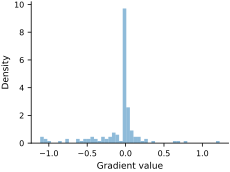

In [11]:
all_grads = jnp.hstack(
    jax.tree_util.tree_map(
        lambda p: p.flatten(),
        jax.tree_util.tree_leaves(g)
    )
)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.hist(all_grads, bins=50, density=True, alpha=0.5)
ax.set(xlabel="Gradient value", ylabel="Density");

It looks better than before, but it is not perfect.
The reason is that Xavier initialization has been designed for sigmoid and tanh activation functions.
For ReLU, we need to use a different initialization.

## He initialization

The He initialization was introduced by {cite:t}`he2015delving`.
The method initializes the weights of a layer with a uniform distribution in the range $[-a, a]$ with $a$ being:

$$
a = \sqrt{\frac{1}{n_{\text{in}}}}
$$

where $n_{\text{in}}$ is the number of inputs to the layer.
This is the default initialization used in `equinox.nn.Linear`.
Let's see how it works:

In [12]:
g = grad_loss(model, X[:, None], y[:, None])
jax.tree_util.tree_leaves(g)

[Array([[-0.137161  ],
        [-0.14594285],
        [ 0.1972345 ],
        [-0.05604376],
        [-0.0023809 ],
        [ 0.00070995],
        [ 0.36193305],
        [ 0.00602406],
        [-0.01431112],
        [ 0.        ]], dtype=float32),
 Array([ 0.09015068,  0.12984118, -0.13102862,  0.05271221, -0.00669131,
        -0.00057694, -0.22451386,  0.00280493, -0.00255928,  0.        ],      dtype=float32),
 Array([[ 1.0778138e-02,  1.2327660e-02,  8.2478148e-04,  1.7101418e-02,
          2.3551367e-02,  2.0171790e-03,  5.2287388e-03,  2.0648468e-02,
          2.0914447e-02,  0.0000000e+00],
        [ 0.0000000e+00, -2.7174037e-03,  0.0000000e+00, -2.0803507e-02,
         -3.9404470e-02, -2.9371942e-03,  1.6780789e-03, -2.9066479e-02,
         -3.0834939e-02,  0.0000000e+00],
        [-1.3764948e-01, -1.4081910e-01, -5.5947408e-02, -4.5996405e-02,
         -1.1695730e-02, -8.3952531e-04, -8.1302613e-02, -8.0701225e-03,
         -8.8563329e-03,  0.0000000e+00],
        [-4.8459396e-

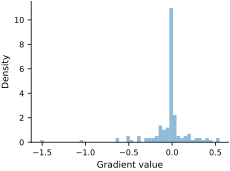

In [13]:
all_grads = jnp.hstack(
    jax.tree_util.tree_map(
        lambda p: p.flatten(),
        jax.tree_util.tree_leaves(g)
    )
)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.hist(all_grads, bins=50, density=True, alpha=0.5)
ax.set(xlabel="Gradient value", ylabel="Density");

It looks better because the gradients are more spread out.

You should use He initialization for ReLU and Xavier initialization for sigmoid and tanh.
You should prefer He initialization for deeper networks.
But at the end of the day, these are just rules of thumb.
You should always look at your gradient histograms and make sure that they are not too peaked at zero.

Let's finish up by seeing how our network can learn:

In [14]:
model, path, losses, test_losses = train_batch(
    model,
    X[:, None], y[:, None],
    optax.adam(0.01),
    X_test[:, None], y_test[:, None],
    n_batch=100,
    n_epochs=100,
    freq=10,
)

Epoch 0, step 0, loss 7.610, test 26.259
Epoch 1, step 0, loss 5.624, test 20.053
Epoch 2, step 0, loss 4.018, test 12.766
Epoch 3, step 0, loss 0.998, test 7.557
Epoch 4, step 0, loss 1.394, test 4.770
Epoch 5, step 0, loss 1.006, test 2.133
Epoch 6, step 0, loss 0.296, test 1.416
Epoch 7, step 0, loss 0.361, test 1.110
Epoch 8, step 0, loss 0.312, test 1.293
Epoch 9, step 0, loss 0.255, test 0.882
Epoch 10, step 0, loss 0.867, test 0.691
Epoch 11, step 0, loss 0.219, test 0.796
Epoch 12, step 0, loss 0.409, test 0.534
Epoch 13, step 0, loss 0.359, test 0.490
Epoch 14, step 0, loss 0.161, test 0.460
Epoch 15, step 0, loss 0.410, test 0.388
Epoch 16, step 0, loss 0.148, test 0.383
Epoch 17, step 0, loss 0.310, test 0.295
Epoch 18, step 0, loss 0.208, test 0.295
Epoch 19, step 0, loss 0.282, test 0.239
Epoch 20, step 0, loss 0.131, test 0.243
Epoch 21, step 0, loss 0.159, test 0.262
Epoch 22, step 0, loss 0.196, test 0.187
Epoch 23, step 0, loss 0.239, test 0.170


Epoch 24, step 0, loss 0.155, test 0.163
Epoch 25, step 0, loss 0.184, test 0.158
Epoch 26, step 0, loss 0.125, test 0.147
Epoch 27, step 0, loss 0.193, test 0.139
Epoch 28, step 0, loss 0.131, test 0.126
Epoch 29, step 0, loss 0.142, test 0.140
Epoch 30, step 0, loss 0.167, test 0.116
Epoch 31, step 0, loss 0.134, test 0.139
Epoch 32, step 0, loss 0.145, test 0.109
Epoch 33, step 0, loss 0.201, test 0.122
Epoch 34, step 0, loss 0.238, test 0.099
Epoch 35, step 0, loss 0.209, test 0.122
Epoch 36, step 0, loss 0.188, test 0.103
Epoch 37, step 0, loss 0.135, test 0.107
Epoch 38, step 0, loss 0.168, test 0.093
Epoch 39, step 0, loss 0.108, test 0.095
Epoch 40, step 0, loss 0.161, test 0.087
Epoch 41, step 0, loss 0.146, test 0.083
Epoch 42, step 0, loss 0.118, test 0.092
Epoch 43, step 0, loss 0.156, test 0.106
Epoch 44, step 0, loss 0.115, test 0.094
Epoch 45, step 0, loss 0.174, test 0.086
Epoch 46, step 0, loss 0.159, test 0.124
Epoch 47, step 0, loss 0.139, test 0.073
Epoch 48, step 0

Epoch 55, step 0, loss 0.148, test 0.082
Epoch 56, step 0, loss 0.126, test 0.074
Epoch 57, step 0, loss 0.163, test 0.080
Epoch 58, step 0, loss 0.127, test 0.087
Epoch 59, step 0, loss 0.146, test 0.074
Epoch 60, step 0, loss 0.106, test 0.079
Epoch 61, step 0, loss 0.193, test 0.087
Epoch 62, step 0, loss 0.112, test 0.082
Epoch 63, step 0, loss 0.123, test 0.081
Epoch 64, step 0, loss 0.160, test 0.085
Epoch 65, step 0, loss 0.125, test 0.087
Epoch 66, step 0, loss 0.193, test 0.068
Epoch 67, step 0, loss 0.154, test 0.073
Epoch 68, step 0, loss 0.117, test 0.096
Epoch 69, step 0, loss 0.126, test 0.070
Epoch 70, step 0, loss 0.144, test 0.081
Epoch 71, step 0, loss 0.140, test 0.075
Epoch 72, step 0, loss 0.143, test 0.080
Epoch 73, step 0, loss 0.120, test 0.066
Epoch 74, step 0, loss 0.136, test 0.081
Epoch 75, step 0, loss 0.134, test 0.118
Epoch 76, step 0, loss 0.144, test 0.071
Epoch 77, step 0, loss 0.161, test 0.070
Epoch 78, step 0, loss 0.112, test 0.108
Epoch 79, step 0

Epoch 82, step 0, loss 0.191, test 0.137
Epoch 83, step 0, loss 0.141, test 0.082
Epoch 84, step 0, loss 0.130, test 0.076
Epoch 85, step 0, loss 0.124, test 0.068
Epoch 86, step 0, loss 0.124, test 0.079
Epoch 87, step 0, loss 0.138, test 0.074
Epoch 88, step 0, loss 0.126, test 0.069
Epoch 89, step 0, loss 0.109, test 0.074
Epoch 90, step 0, loss 0.146, test 0.100
Epoch 91, step 0, loss 0.137, test 0.070
Epoch 92, step 0, loss 0.156, test 0.064
Epoch 93, step 0, loss 0.112, test 0.092
Epoch 94, step 0, loss 0.095, test 0.075
Epoch 95, step 0, loss 0.137, test 0.072
Epoch 96, step 0, loss 0.119, test 0.066
Epoch 97, step 0, loss 0.151, test 0.072
Epoch 98, step 0, loss 0.145, test 0.082
Epoch 99, step 0, loss 0.141, test 0.068


Here is the evolution of the loss:

array([<Axes: title={'center': 'Loss'}, xlabel='Iteration $\\times$ 100', ylabel='Loss'>],
      dtype=object)

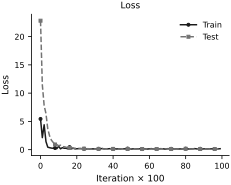

In [15]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
markevery = max(1, len(losses) // 12)
ax.plot(losses, color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="Train")
ax.plot(test_losses, color="0.45", linestyle="--", marker="s", markevery=markevery, markersize=3, label="Test")
ax.set(xlabel="Iteration $\\times$ 100", ylabel="Loss", title="Loss")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

Let's make some predictions:

array([<Axes: title={'center': 'Model fit'}, xlabel='x', ylabel='y'>],
      dtype=object)

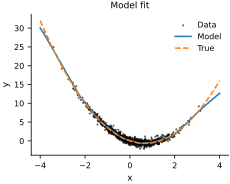

In [16]:
xs = jnp.linspace(-4, 4, 100)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.scatter(X, y, color='black', label="Data", alpha=0.5, s=2)
ax.plot(xs, model(xs[:, None]).flatten(), label="Model")
ax.plot(xs, 1.5 * xs ** 2 - 2 * xs, '--', label="True")
ax.set(xlabel="x", ylabel="y", title="Model fit")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

The fit looks good. It is not perfect because we are using a stupid model (we should have used a simple polynomial regression), but it is good enough to demonstrate the basic concepts.